# NSGD vs LSTM-PPO - Monitor-Based Evaluation

This notebook compares NSGD and LSTM-PPO using `monitor.csv` instead of `request_log.csv`.

The monitor samples state every ~0.1 seconds, so the scientifically safer comparison is **time-weighted**:

- State terms (`idle_on`, `busy`, `init_total`, `init_reserved`) are integrated over the time until the next sample.
- Rejections are not averaged as a boolean flag. They are counted with `rejected_requests_interval` and charged as discrete event penalties.
- The combined loss is reported as both total loss and loss per second, using a common evaluation window for both models.

In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.9,
})

# Edit these two directories if you want a different pair of runs.
NSGD_DIR = Path('logs/nsgd_const_6_hours_with_new_handler_eval_eval_last_eval')
LSTM_PPO_DIR = Path('logs/rl_const_6_hours_with_new_handler_eval_eval_last_eval')
NSGD_DIR_48 = Path('logs/nsgd_last_run_after_48_hours_evaluate')
LSTM_PPO_DIR_48 = Path('logs/rl_last_final_train_after_48_hours_eval_last_last')
OUT_DIR = Path('logs/monitor_comparison')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Compare the same horizon from the beginning of each run.
WINDOW_MINUTES = 90
BUCKET_SECONDS = 30
MAX_VALID_DT_SECONDS = 1.0

# Cost weights used by experiment_metrics.py / app.py.
W_IDLE_ON = 2
W_BUSY = 1
W_INIT = 5
W_RESERVED = 100
W_REJ = 200

COLOR_NSGD = '#1f77b4'
COLOR_PPO = '#ff7f0e'

print('NSGD monitor:', NSGD_DIR / 'monitor.csv')
print('LSTM-PPO monitor:', LSTM_PPO_DIR / 'monitor.csv')

NSGD monitor: logs/nsgd_const_6_hours_with_new_handler_eval_eval_last_eval/monitor.csv
LSTM-PPO monitor: logs/rl_const_6_hours_with_new_handler_eval_eval_last_eval/monitor.csv


## Method

For a monitor row at time `t_i`, the state is treated as valid until the next row `t_{i+1}`. That gives `dt_i = t_{i+1} - t_i`.

The state part of loss is integrated as:

`sum(state_cost_i * dt_i)`

where:

`state_cost = 2*idle_on + 1*busy + 5*init_total + 100*init_reserved`

The rejection part is an impulse/event penalty:

`200 * sum(rejected_requests_interval)`

So the final monitor loss is:

`total_loss = integrated_state_loss + rejection_event_loss`

This avoids the common mistake of multiplying rejection penalties by the 0.1 second sample duration.

In [6]:
def _to_bool(series):
    if series.dtype == bool:
        return series
    if series.dtype == object:
        return series.astype(str).str.lower().isin(['true', '1', 'yes'])
    return series.fillna(0).astype(float) != 0


def load_monitor(run_dir, label):
    path = Path(run_dir) / 'monitor.csv'
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path)
    required = ['timestamp', 'idle_on', 'busy', 'init_total', 'init_reserved']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'{path} is missing required columns: {missing}')

    df = df.sort_values('timestamp').drop_duplicates('timestamp').reset_index(drop=True)
    df['label'] = label
    df['seconds_from_start'] = df['timestamp'] - df['timestamp'].iloc[0]
    df['minutes_from_start'] = df['seconds_from_start'] / 60

    if 'rejected_requests_interval' not in df.columns:
        if 'has_rejection' in df.columns:
            df['rejected_requests_interval'] = _to_bool(df['has_rejection']).astype(int)
        else:
            df['rejected_requests_interval'] = 0

    if 'has_rejection' in df.columns:
        df['has_rejection'] = _to_bool(df['has_rejection'])
    else:
        df['has_rejection'] = df['rejected_requests_interval'] > 0

    numeric_cols = [
        'idle_on', 'busy', 'init_total', 'init_reserved', 'cold',
        'total_pods', 'ready_pods', 'not_ready_pods', 'inflight_requests',
        'rejected_requests_interval', 'rejected_requests', 'nsgd_cost',
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    df = df[df['minutes_from_start'] <= WINDOW_MINUTES].copy()
    df['next_timestamp'] = df['timestamp'].shift(-1)
    df['dt'] = df['next_timestamp'] - df['timestamp']

    median_dt = df['dt'].dropna().median()
    if not np.isfinite(median_dt) or median_dt <= 0:
        median_dt = 0.1
    df['dt'] = df['dt'].fillna(median_dt).clip(lower=0, upper=MAX_VALID_DT_SECONDS)

    df['state_cost_rate'] = (
        W_IDLE_ON * df['idle_on']
        + W_BUSY * df['busy']
        + W_INIT * df['init_total']
        + W_RESERVED * df['init_reserved']
    )
    df['rejection_cost'] = W_REJ * df['rejected_requests_interval']
    df['state_loss_area'] = df['state_cost_rate'] * df['dt']
    df['total_loss_increment'] = df['state_loss_area'] + df['rejection_cost']
    df['cumulative_state_loss'] = df['state_loss_area'].cumsum()
    df['cumulative_rejection_loss'] = df['rejection_cost'].cumsum()
    df['cumulative_total_loss'] = df['total_loss_increment'].cumsum()
    df['cum_rejections'] = df['rejected_requests_interval'].cumsum()
    return df.reset_index(drop=True)


nsgd_raw = load_monitor(NSGD_DIR, 'NSGD')
ppo_raw = load_monitor(LSTM_PPO_DIR, 'LSTM-PPO')

common_duration = min(nsgd_raw['seconds_from_start'].max(), ppo_raw['seconds_from_start'].max(), WINDOW_MINUTES * 60)
nsgd_raw = nsgd_raw[nsgd_raw['seconds_from_start'] <= common_duration].copy()
ppo_raw = ppo_raw[ppo_raw['seconds_from_start'] <= common_duration].copy()

print(f'Common comparison duration: {common_duration/60:.2f} minutes')
print(f'NSGD rows: {len(nsgd_raw):,}, monitor seconds: {nsgd_raw["dt"].sum():.1f}, rejections: {int(nsgd_raw["rejected_requests_interval"].sum())}')
print(f'LSTM-PPO rows: {len(ppo_raw):,}, monitor seconds: {ppo_raw["dt"].sum():.1f}, rejections: {int(ppo_raw["rejected_requests_interval"].sum())}')

Common comparison duration: 90.00 minutes
NSGD rows: 59,361, monitor seconds: 5400.1, rejections: 584
LSTM-PPO rows: 59,530, monitor seconds: 5400.0, rejections: 463


In [7]:
def summarize_monitor(df):
    duration = df['dt'].sum()
    if duration <= 0:
        raise ValueError('Non-positive monitored duration')

    def tw_mean(col):
        return (df[col] * df['dt']).sum() / duration if col in df.columns else np.nan

    state_loss = df['state_loss_area'].sum()
    rejection_loss = df['rejection_cost'].sum()
    total_loss = state_loss + rejection_loss
    rejections = df['rejected_requests_interval'].sum()

    return pd.Series({
        'duration_min': duration / 60,
        'total_loss': total_loss,
        'loss_per_second': total_loss / duration,
        'state_loss_per_second': state_loss / duration,
        'rejection_loss_per_second': rejection_loss / duration,
        'total_rejections': rejections,
        'rejections_per_minute': rejections / (duration / 60),
        'avg_cold': tw_mean('cold'),
        'avg_idle_on': tw_mean('idle_on'),
        'avg_busy': tw_mean('busy'),
        'avg_init_total': tw_mean('init_total'),
        'avg_init_reserved': tw_mean('init_reserved'),
        'avg_inflight_requests': tw_mean('inflight_requests'),
        'mean_sample_gap_ms': df['dt'].mean() * 1000,
        'p95_sample_gap_ms': df['dt'].quantile(0.95) * 1000,
    })

summary = pd.DataFrame({
    'NSGD': summarize_monitor(nsgd_raw),
    'LSTM-PPO': summarize_monitor(ppo_raw),
}).T

summary['loss_delta_vs_lstm_ppo'] = summary['loss_per_second'] - summary.loc['LSTM-PPO', 'loss_per_second']
summary['loss_ratio_vs_lstm_ppo'] = summary['loss_per_second'] / summary.loc['LSTM-PPO', 'loss_per_second']
summary.round(3)

,duration_min,total_loss,loss_per_second,state_loss_per_second,rejection_loss_per_second,total_rejections,rejections_per_minute,avg_cold,avg_idle_on,avg_busy,avg_init_total,avg_init_reserved,avg_inflight_requests,mean_sample_gap_ms,p95_sample_gap_ms,loss_delta_vs_lstm_ppo,loss_ratio_vs_lstm_ppo
NSGD,90.001,195778.554,36.255,14.625,21.629,584.0,6.489,15.918,6.409,1.64,0.034,0.0,1.64,90.97,100.395,-4.919,0.881
LSTM-PPO,90.000,222339.656,41.174,24.026,17.148,463.0,5.144,11.308,11.011,1.60,0.081,0.0,1.60,90.71,100.411,0.000,1.000


FOR 48 Hours 2 Code Blocks

## Samples Throughput and LSTM-PPO Reward

`monitor.csv` is best for state-cost integration, but throughput and LSTM-PPO reward are recorded in `samples.csv` on the periodic sampling window. This section aligns `samples.csv` to the same monitor comparison horizon and plots those two metrics.

In [8]:
def load_samples(run_dir, label, monitor_start_timestamp, duration_seconds):
    path = Path(run_dir) / 'samples.csv'
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path).sort_values('timestamp').reset_index(drop=True)
    df = df[
        (df['timestamp'] >= monitor_start_timestamp)
        & (df['timestamp'] <= monitor_start_timestamp + duration_seconds)
    ].copy()

    numeric_cols = [
        'throughput', 'lstm_ppo_reward', 'avg_execution_time', 'requests',
        'proxy_requests', 'proxy_rejections', 'avg_response_latency_ms',
        'p99_response_latency_ms', 'replicas', 'nsgd_cost',
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['label'] = label
    df['seconds_from_start'] = df['timestamp'] - monitor_start_timestamp
    df['minutes_from_start'] = df['seconds_from_start'] / 60

    if len(df) > 1:
        sample_dt = df['timestamp'].shift(-1) - df['timestamp']
        median_dt = sample_dt.dropna().median()
        if not np.isfinite(median_dt) or median_dt <= 0:
            median_dt = SAMPLING_WINDOW if 'SAMPLING_WINDOW' in globals() else 30
        df['dt'] = sample_dt.fillna(median_dt).clip(lower=0, upper=median_dt * 1.5)
    else:
        df['dt'] = 0.0

    return df.reset_index(drop=True)


def summarize_samples(df):
    duration = df['dt'].sum()
    if duration <= 0:
        duration = len(df)
        weights = pd.Series(1.0, index=df.index)
    else:
        weights = df['dt']

    def weighted_mean(col):
        if col not in df.columns or df[col].dropna().empty:
            return np.nan
        valid = df[col].notna()
        return (df.loc[valid, col] * weights.loc[valid]).sum() / weights.loc[valid].sum()

    return pd.Series({
        'sample_rows': len(df),
        'sample_duration_min': duration / 60 if duration != len(df) else np.nan,
        'avg_throughput_percent': weighted_mean('throughput'),
        'avg_lstm_ppo_reward': weighted_mean('lstm_ppo_reward'),
        'avg_sample_execution_time_s': weighted_mean('avg_execution_time'),
        'total_sample_proxy_requests': df['proxy_requests'].sum() if 'proxy_requests' in df.columns else np.nan,
        'total_sample_proxy_rejections': df['proxy_rejections'].sum() if 'proxy_rejections' in df.columns else np.nan,
    })

nsgd_samples = load_samples(NSGD_DIR, 'NSGD', nsgd_raw['timestamp'].iloc[0], common_duration)
ppo_samples = load_samples(LSTM_PPO_DIR, 'LSTM-PPO', ppo_raw['timestamp'].iloc[0], common_duration)

sample_summary = pd.DataFrame({
    'NSGD': summarize_samples(nsgd_samples),
    'LSTM-PPO': summarize_samples(ppo_samples),
}).T

sample_summary.round(3)

,sample_rows,sample_duration_min,avg_throughput_percent,avg_lstm_ppo_reward,avg_sample_execution_time_s,total_sample_proxy_requests,total_sample_proxy_rejections
NSGD,179.0,89.545,81.362,5042.834,4.151,2673.0,577.0
LSTM-PPO,179.0,89.546,85.304,5526.779,3.899,2675.0,459.0


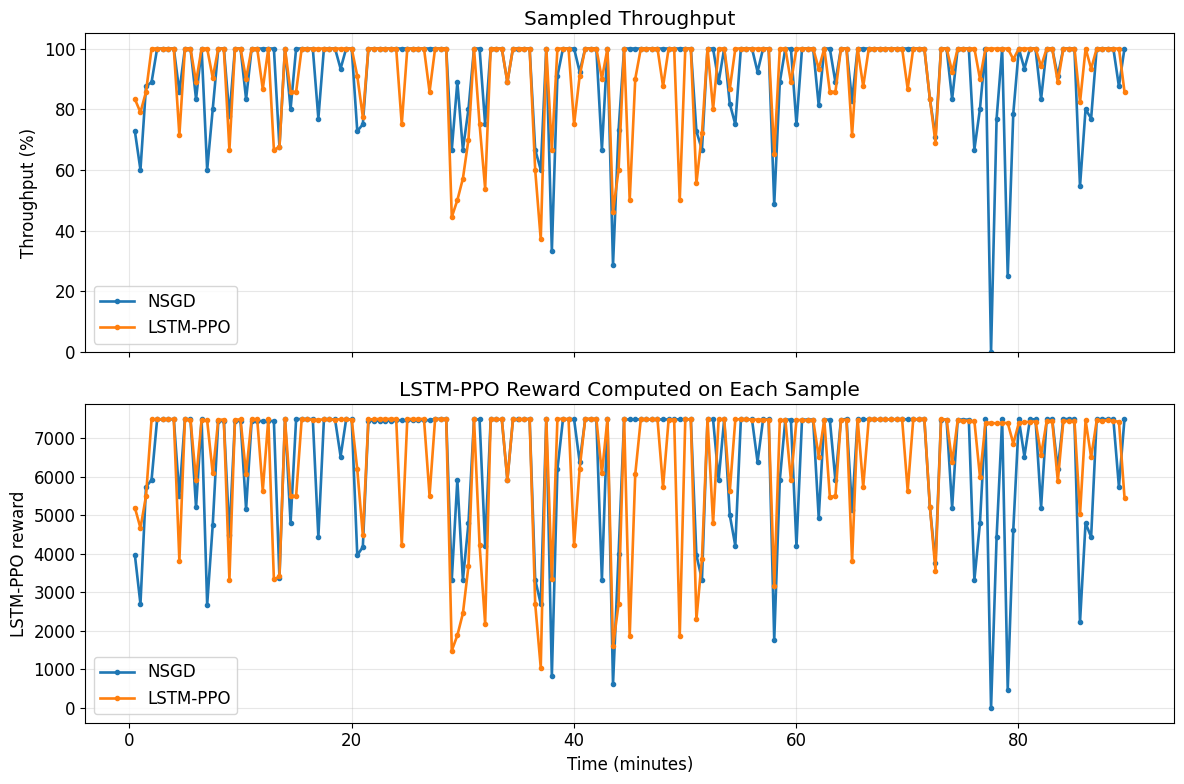

,avg_throughput_percent,avg_lstm_ppo_reward,avg_sample_execution_time_s,total_sample_proxy_requests,total_sample_proxy_rejections
NSGD,91.601,6464.879,2.483,1253.0,246.0
LSTM-PPO,92.476,6537.430,2.792,1253.0,235.0


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(
    nsgd_samples['minutes_from_start'], nsgd_samples['throughput'],
    color=COLOR_NSGD, marker='o', markersize=3, label='NSGD'
)
axes[0].plot(
    ppo_samples['minutes_from_start'], ppo_samples['throughput'],
    color=COLOR_PPO, marker='o', markersize=3, label='LSTM-PPO'
)
axes[0].set_ylabel('Throughput (%)')
axes[0].set_title('Sampled Throughput')
axes[0].set_ylim(0, 105)
axes[0].legend()

axes[1].plot(
    nsgd_samples['minutes_from_start'], nsgd_samples['lstm_ppo_reward'],
    color=COLOR_NSGD, marker='o', markersize=3, label='NSGD'
)
axes[1].plot(
    ppo_samples['minutes_from_start'], ppo_samples['lstm_ppo_reward'],
    color=COLOR_PPO, marker='o', markersize=3, label='LSTM-PPO'
)
axes[1].set_xlabel('Time (minutes)')
axes[1].set_ylabel('LSTM-PPO reward')
axes[1].set_title('LSTM-PPO Reward Computed on Each Sample')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'samples_throughput_and_lstm_ppo_reward.png', dpi=150, bbox_inches='tight')
plt.show()

sample_summary[['avg_throughput_percent', 'avg_lstm_ppo_reward', 'avg_sample_execution_time_s', 'total_sample_proxy_requests', 'total_sample_proxy_rejections']].round(3)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample_summary['avg_throughput_percent'].plot(
    kind='bar', ax=axes[0], color=[COLOR_NSGD, COLOR_PPO]
)
axes[0].set_title('Average Sampled Throughput')
axes[0].set_ylabel('Throughput (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 105)

sample_summary['avg_lstm_ppo_reward'].plot(
    kind='bar', ax=axes[1], color=[COLOR_NSGD, COLOR_PPO]
)
axes[1].set_title('Average LSTM-PPO Reward')
axes[1].set_ylabel('Reward')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(OUT_DIR / 'samples_avg_throughput_and_reward.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
def _to_bool(series):
    if series.dtype == bool:
        return series
    if series.dtype == object:
        return series.astype(str).str.lower().isin(['true', '1', 'yes'])
    return series.fillna(0).astype(float) != 0


def load_monitor(run_dir, label):
    path = Path(run_dir) / 'monitor.csv'
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path)
    required = ['timestamp', 'idle_on', 'busy', 'init_total', 'init_reserved']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'{path} is missing required columns: {missing}')

    df = df.sort_values('timestamp').drop_duplicates('timestamp').reset_index(drop=True)
    df['label'] = label
    df['seconds_from_start'] = df['timestamp'] - df['timestamp'].iloc[0]
    df['minutes_from_start'] = df['seconds_from_start'] / 60

    if 'rejected_requests_interval' not in df.columns:
        if 'has_rejection' in df.columns:
            df['rejected_requests_interval'] = _to_bool(df['has_rejection']).astype(int)
        else:
            df['rejected_requests_interval'] = 0

    if 'has_rejection' in df.columns:
        df['has_rejection'] = _to_bool(df['has_rejection'])
    else:
        df['has_rejection'] = df['rejected_requests_interval'] > 0

    numeric_cols = [
        'idle_on', 'busy', 'init_total', 'init_reserved', 'cold',
        'total_pods', 'ready_pods', 'not_ready_pods', 'inflight_requests',
        'rejected_requests_interval', 'rejected_requests', 'nsgd_cost',
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    df = df[df['minutes_from_start'] <= WINDOW_MINUTES].copy()
    df['next_timestamp'] = df['timestamp'].shift(-1)
    df['dt'] = df['next_timestamp'] - df['timestamp']

    median_dt = df['dt'].dropna().median()
    if not np.isfinite(median_dt) or median_dt <= 0:
        median_dt = 0.1
    df['dt'] = df['dt'].fillna(median_dt).clip(lower=0, upper=MAX_VALID_DT_SECONDS)

    df['state_cost_rate'] = (
        W_IDLE_ON * df['idle_on']
        + W_BUSY * df['busy']
        + W_INIT * df['init_total']
        + W_RESERVED * df['init_reserved']
    )
    df['rejection_cost'] = W_REJ * df['rejected_requests_interval']
    df['state_loss_area'] = df['state_cost_rate'] * df['dt']
    df['total_loss_increment'] = df['state_loss_area'] + df['rejection_cost']
    df['cumulative_state_loss'] = df['state_loss_area'].cumsum()
    df['cumulative_rejection_loss'] = df['rejection_cost'].cumsum()
    df['cumulative_total_loss'] = df['total_loss_increment'].cumsum()
    df['cum_rejections'] = df['rejected_requests_interval'].cumsum()
    return df.reset_index(drop=True)


nsgd_48_raw = load_monitor(NSGD_DIR_48, 'NSGD_48')
ppo_48_raw = load_monitor(LSTM_PPO_DIR_48, 'LSTM-PPO_48')

common_duration = min(nsgd_raw['seconds_from_start'].max(), ppo_raw['seconds_from_start'].max(), WINDOW_MINUTES * 60)
nsgd_raw = nsgd_raw[nsgd_raw['seconds_from_start'] <= common_duration].copy()
ppo_raw = ppo_raw[ppo_raw['seconds_from_start'] <= common_duration].copy()

print(f'Common comparison duration: {common_duration/60:.2f} minutes')
print(f'NSGD rows: {len(nsgd_raw):,}, monitor seconds: {nsgd_raw["dt"].sum():.1f}, rejections: {int(nsgd_raw["rejected_requests_interval"].sum())}')
print(f'LSTM-PPO rows: {len(ppo_raw):,}, monitor seconds: {ppo_raw["dt"].sum():.1f}, rejections: {int(ppo_raw["rejected_requests_interval"].sum())}')

Common comparison duration: 90.00 minutes
NSGD rows: 53,829, monitor seconds: 5399.9, rejections: 203
LSTM-PPO rows: 53,859, monitor seconds: 5399.9, rejections: 210


In [5]:
def summarize_monitor(df):
    duration = df['dt'].sum()
    if duration <= 0:
        raise ValueError('Non-positive monitored duration')

    def tw_mean(col):
        return (df[col] * df['dt']).sum() / duration if col in df.columns else np.nan

    state_loss = df['state_loss_area'].sum()
    rejection_loss = df['rejection_cost'].sum()
    total_loss = state_loss + rejection_loss
    rejections = df['rejected_requests_interval'].sum()

    return pd.Series({
        'duration_min': duration / 60,
        'total_loss': total_loss,
        'loss_per_second': total_loss / duration,
        'state_loss_per_second': state_loss / duration,
        'rejection_loss_per_second': rejection_loss / duration,
        'total_rejections': rejections,
        'rejections_per_minute': rejections / (duration / 60),
        'avg_cold': tw_mean('cold'),
        'avg_idle_on': tw_mean('idle_on'),
        'avg_busy': tw_mean('busy'),
        'avg_init_total': tw_mean('init_total'),
        'avg_init_reserved': tw_mean('init_reserved'),
        'avg_inflight_requests': tw_mean('inflight_requests'),
        'mean_sample_gap_ms': df['dt'].mean() * 1000,
        'p95_sample_gap_ms': df['dt'].quantile(0.95) * 1000,
    })

summary = pd.DataFrame({
    'NSGD': summarize_monitor(nsgd_48_raw),
    'LSTM-PPO': summarize_monitor(ppo_48_raw),
}).T

summary['loss_delta_vs_lstm_ppo'] = summary['loss_per_second'] - summary.loc['LSTM-PPO', 'loss_per_second']
summary['loss_ratio_vs_lstm_ppo'] = summary['loss_per_second'] / summary.loc['LSTM-PPO', 'loss_per_second']
summary.round(3)

,duration_min,total_loss,loss_per_second,state_loss_per_second,rejection_loss_per_second,total_rejections,rejections_per_minute,avg_cold,avg_idle_on,avg_busy,avg_init_total,avg_init_reserved,avg_inflight_requests,mean_sample_gap_ms,p95_sample_gap_ms,loss_delta_vs_lstm_ppo,loss_ratio_vs_lstm_ppo
NSGD,90.002,124148.772,22.990,14.583,8.407,227.0,2.522,16.593,6.846,0.488,0.073,0.0,0.488,100.275,100.323,-4.073,0.849
LSTM-PPO,90.001,146144.444,27.064,20.101,6.963,188.0,2.089,13.807,9.618,0.503,0.072,0.0,0.503,100.255,100.303,0.000,1.000


In [ ]:
def aggregate_monitor_windows(df, bucket_seconds=BUCKET_SECONDS):
    df = df.copy()
    df['bucket'] = (df['seconds_from_start'] // bucket_seconds).astype(int)
    rows = []
    for bucket, g in df.groupby('bucket', sort=True):
        duration = g['dt'].sum()
        if duration <= 0:
            continue

        def tw_mean(col):
            return (g[col] * g['dt']).sum() / duration if col in g.columns else np.nan

        rejections = g['rejected_requests_interval'].sum()
        state_loss = g['state_loss_area'].sum()
        rejection_loss = g['rejection_cost'].sum()
        total_loss = state_loss + rejection_loss
        rows.append({
            'bucket': bucket,
            'seconds_from_start': bucket * bucket_seconds,
            'minutes_from_start': bucket * bucket_seconds / 60,
            'duration': duration,
            'state_cost_rate': state_loss / duration,
            'rejection_cost_rate': rejection_loss / duration,
            'total_loss_rate': total_loss / duration,
            'rejections': rejections,
            'rejections_per_min': rejections / (duration / 60),
            'cum_rejections': g['cum_rejections'].iloc[-1],
            'cumulative_total_loss': g['cumulative_total_loss'].iloc[-1],
            'cold': tw_mean('cold'),
            'idle_on': tw_mean('idle_on'),
            'busy': tw_mean('busy'),
            'init_total': tw_mean('init_total'),
            'init_reserved': tw_mean('init_reserved'),
            'inflight_requests': tw_mean('inflight_requests'),
            'ready_pods': tw_mean('ready_pods'),
            'not_ready_pods': tw_mean('not_ready_pods'),
        })
    return pd.DataFrame(rows)

nsgd = aggregate_monitor_windows(nsgd_raw)
ppo = aggregate_monitor_windows(ppo_raw)
print(nsgd.head())

   bucket  seconds_from_start  minutes_from_start   duration  state_cost_rate  \
0       0                   0                 0.0  30.021713        22.784707   
1       1                  30                 0.5  29.997416        13.950637   
2       2                  60                 1.0  29.998384        28.043345   
3       3                  90                 1.5  29.987869        29.622033   
4       4                 120                 2.0  30.093094        28.706558   

   rejection_cost_rate  total_loss_rate  rejections  rejections_per_min  \
0             0.000000        22.784707           0            0.000000   
1            26.668964        40.619601           4            8.000689   
2            46.669181        74.712526           7           14.000754   
3             6.669364        36.291397           1            2.000809   
4             6.646043        35.352601           1            1.993813   

   cum_rejections  cumulative_total_loss       cold    idle_on

## Overall Loss

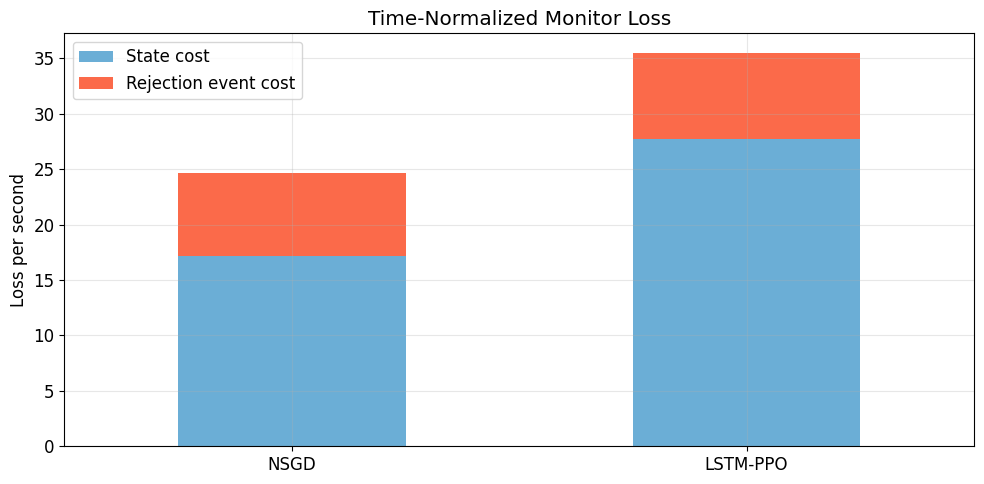

,duration_min,loss_per_second,state_loss_per_second,rejection_loss_per_second,total_rejections,rejections_per_minute
NSGD,89.999,24.686,17.167,7.519,203.0,2.256
LSTM-PPO,90.000,35.469,27.692,7.778,210.0,2.333


In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_cols = ['state_loss_per_second', 'rejection_loss_per_second']
summary[plot_cols].plot(kind='bar', stacked=True, color=['#6baed6', '#fb6a4a'], ax=ax)
ax.set_ylabel('Loss per second')
ax.set_title('Time-Normalized Monitor Loss')
ax.set_xlabel('')
ax.legend(['State cost', 'Rejection event cost'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'monitor_loss_per_second_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

summary[['duration_min', 'loss_per_second', 'state_loss_per_second', 'rejection_loss_per_second', 'total_rejections', 'rejections_per_minute']].round(3)

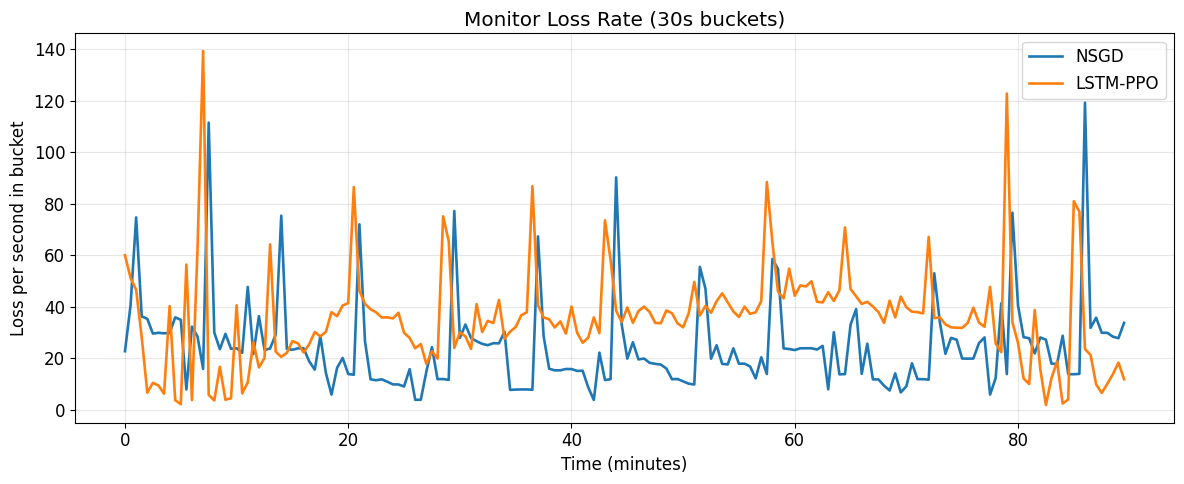

In [22]:
fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['total_loss_rate'], color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['total_loss_rate'], color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Loss per second in bucket')
ax.set_title(f'Monitor Loss Rate ({BUCKET_SECONDS}s buckets)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'monitor_loss_rate.png', dpi=150, bbox_inches='tight')
plt.show()

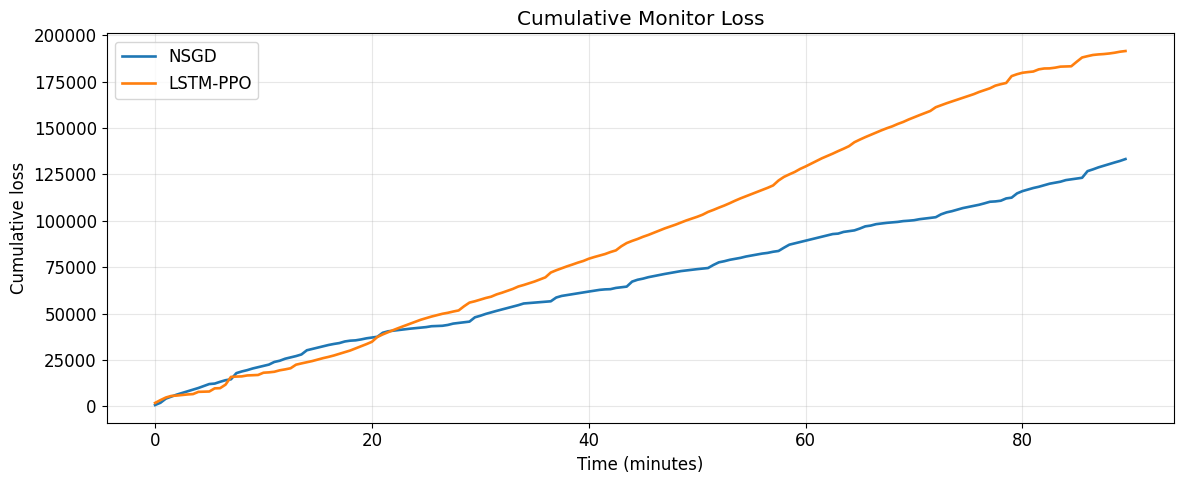

In [23]:
fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['cumulative_total_loss'], color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['cumulative_total_loss'], color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Cumulative loss')
ax.set_title('Cumulative Monitor Loss')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'monitor_cumulative_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## Rejections

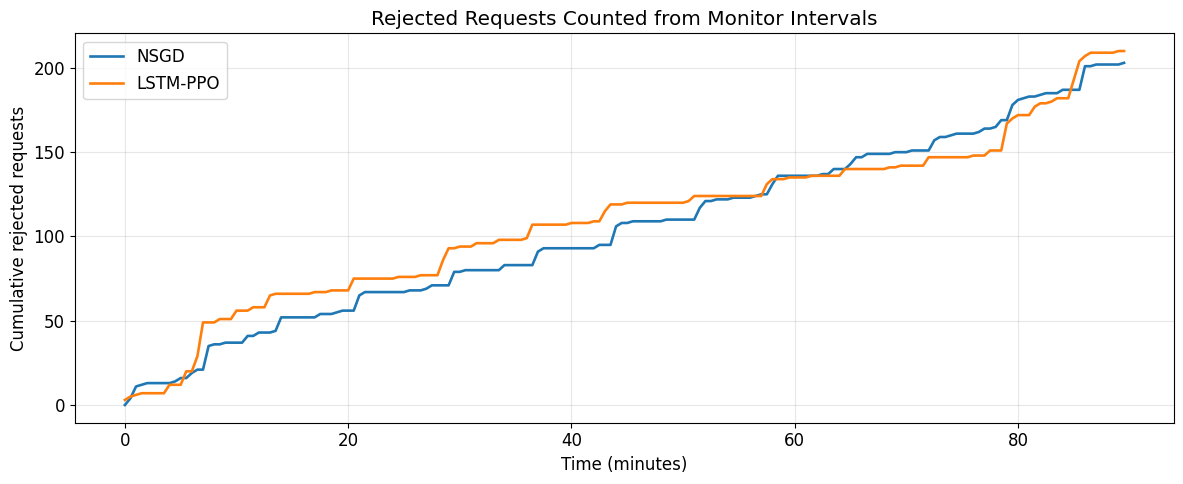

NSGD total rejections: 203
LSTM-PPO total rejections: 210


In [24]:
fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['cum_rejections'], color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['cum_rejections'], color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Cumulative rejected requests')
ax.set_title('Rejected Requests Counted from Monitor Intervals')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'monitor_cumulative_rejections.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NSGD total rejections: {int(summary.loc["NSGD", "total_rejections"])}')
print(f'LSTM-PPO total rejections: {int(summary.loc["LSTM-PPO", "total_rejections"])}')

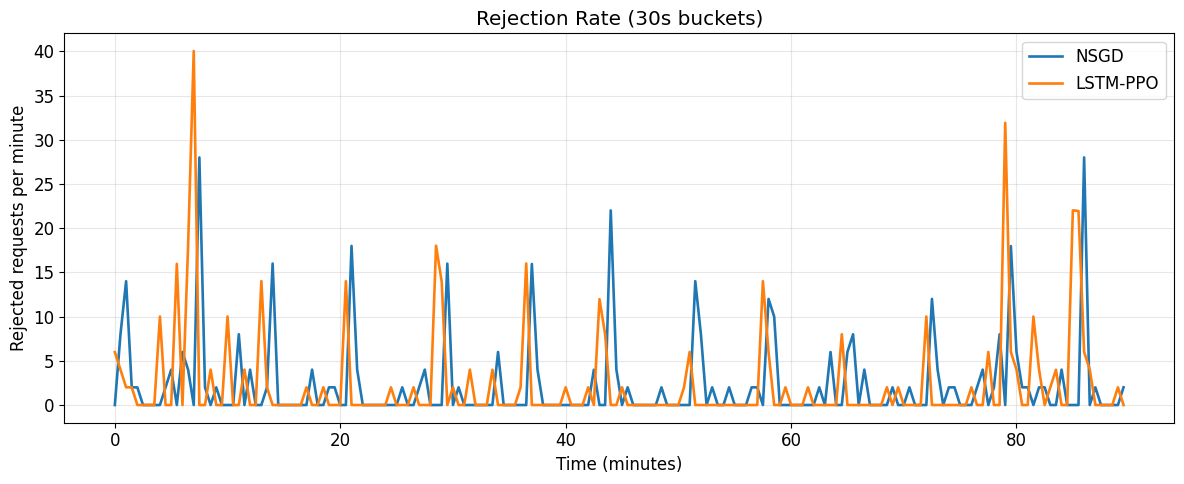

In [25]:
fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['rejections_per_min'], color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['rejections_per_min'], color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Rejected requests per minute')
ax.set_title(f'Rejection Rate ({BUCKET_SECONDS}s buckets)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'monitor_rejection_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## State Occupancy

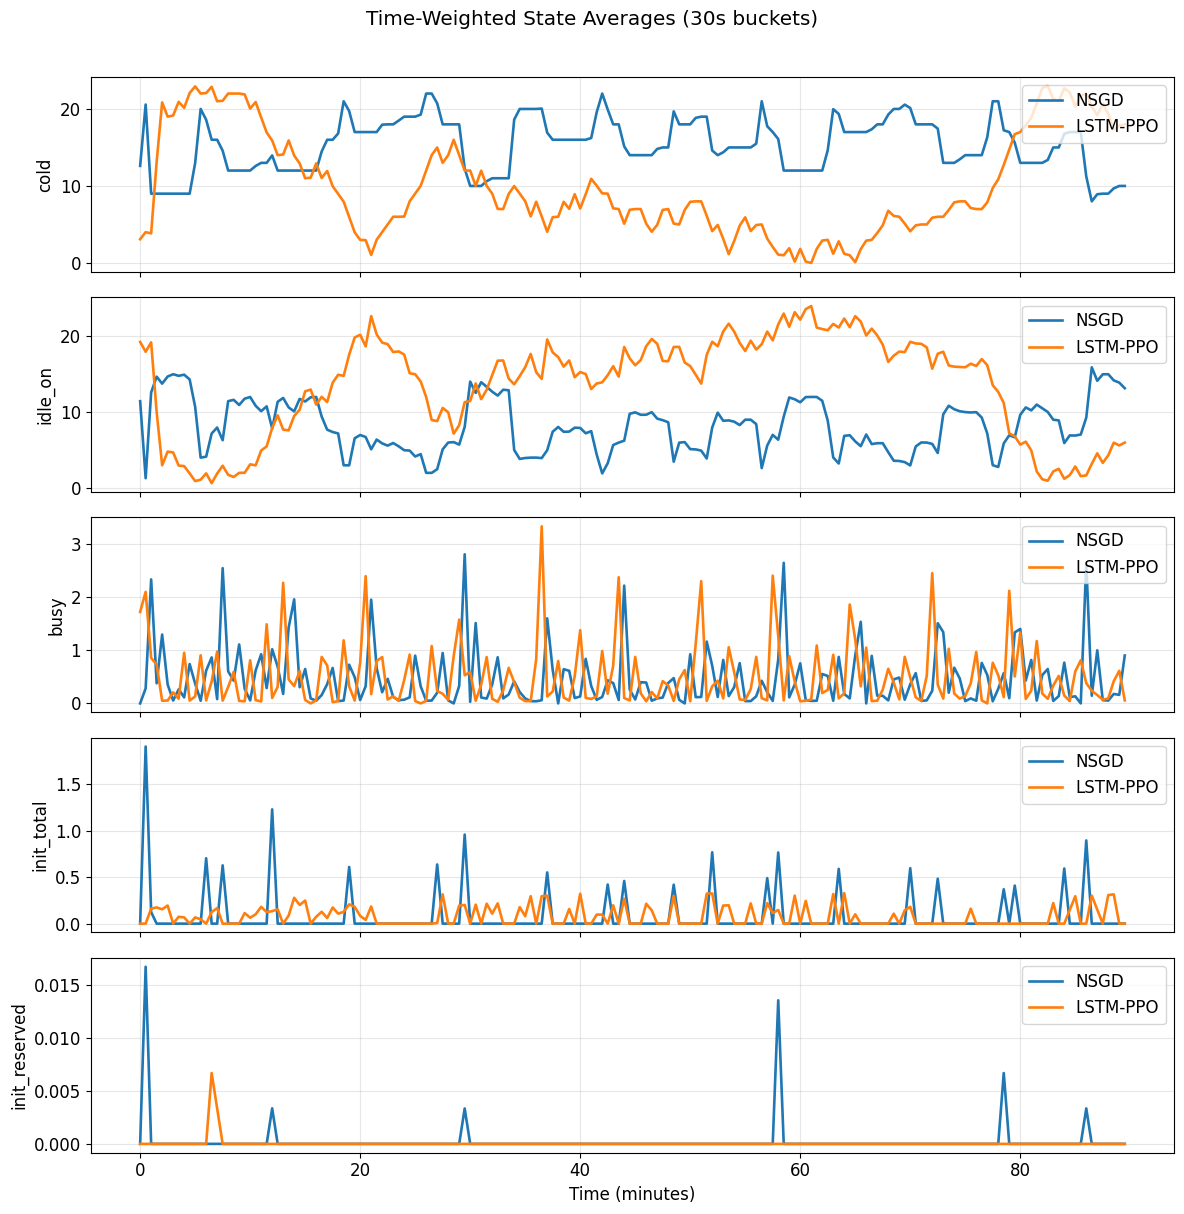

In [26]:
state_cols = ['cold', 'idle_on', 'busy', 'init_total', 'init_reserved']
fig, axes = plt.subplots(len(state_cols), 1, figsize=(12, 12), sharex=True)
for ax, col in zip(axes, state_cols):
    ax.plot(nsgd['minutes_from_start'], nsgd[col], color=COLOR_NSGD, label='NSGD')
    ax.plot(ppo['minutes_from_start'], ppo[col], color=COLOR_PPO, label='LSTM-PPO')
    ax.set_ylabel(col)
    ax.legend(loc='upper right')
axes[-1].set_xlabel('Time (minutes)')
fig.suptitle(f'Time-Weighted State Averages ({BUCKET_SECONDS}s buckets)', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'monitor_state_occupancy.png', dpi=150, bbox_inches='tight')
plt.show()

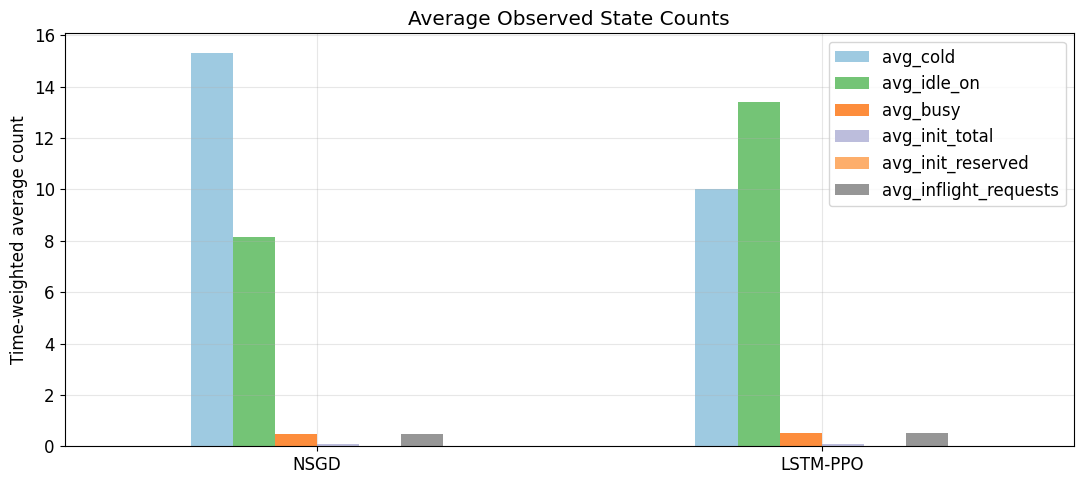

,avg_cold,avg_idle_on,avg_busy,avg_init_total,avg_init_reserved,avg_inflight_requests
NSGD,15.315,8.132,0.472,0.081,0.0,0.473
LSTM-PPO,10.022,13.396,0.504,0.078,0.0,0.505


In [27]:
state_summary = summary[['avg_cold', 'avg_idle_on', 'avg_busy', 'avg_init_total', 'avg_init_reserved', 'avg_inflight_requests']]
ax = state_summary.plot(kind='bar', figsize=(11, 5), color=['#9ecae1', '#74c476', '#fd8d3c', '#bcbddc', '#fdae6b', '#969696'])
ax.set_ylabel('Time-weighted average count')
ax.set_title('Average Observed State Counts')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'monitor_state_summary.png', dpi=150, bbox_inches='tight')
plt.show()

state_summary.round(3)

## Additional Evaluation Pair: NSGD Eval vs LSTM-PPO 6-Hour Eval

This section compares `logs/nsgd_last_run_eval/samples.csv` with `logs/rl_last_final_evaluate_6_hours/samples.csv` using the same first-window alignment approach. It does not concatenate these runs with the 48-hour evaluation pair above.

In [ ]:
NSGD_EVAL_DIR = Path('logs/nsgd_last_run_eval')
LSTM_PPO_EVAL_6H_DIR = Path('logs/rl_last_final_evaluate_6_hours')


def load_sample_pair_for_dirs(nsgd_dir, ppo_dir, window_minutes=WINDOW_MINUTES):
    def monitor_start_and_duration(run_dir):
        monitor_path = Path(run_dir) / 'monitor.csv'
        if monitor_path.exists():
            monitor = pd.read_csv(monitor_path, usecols=['timestamp']).sort_values('timestamp')
            start = float(monitor['timestamp'].iloc[0])
            duration = min(window_minutes * 60, float(monitor['timestamp'].iloc[-1] - start))
            return start, duration

        samples = pd.read_csv(Path(run_dir) / 'samples.csv', usecols=['timestamp']).sort_values('timestamp')
        start = float(samples['timestamp'].iloc[0])
        duration = min(window_minutes * 60, float(samples['timestamp'].iloc[-1] - start))
        return start, duration

    def load_one(run_dir, label, start, duration):
        df = pd.read_csv(Path(run_dir) / 'samples.csv').sort_values('timestamp').reset_index(drop=True)
        df = df[(df['timestamp'] >= start) & (df['timestamp'] <= start + duration)].copy()
        numeric_cols = [
            'throughput', 'lstm_ppo_reward', 'avg_execution_time', 'requests',
            'proxy_requests', 'proxy_rejections', 'avg_response_latency_ms',
            'p99_response_latency_ms', 'replicas', 'nsgd_cost',
        ]
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        df['label'] = label
        df['seconds_from_start'] = df['timestamp'] - start
        df['minutes_from_start'] = df['seconds_from_start'] / 60
        if len(df) > 1:
            sample_dt = df['timestamp'].shift(-1) - df['timestamp']
            median_dt = sample_dt.dropna().median()
            if not np.isfinite(median_dt) or median_dt <= 0:
                median_dt = 30.0
            df['dt'] = sample_dt.fillna(median_dt).clip(lower=0, upper=median_dt * 1.5)
        else:
            df['dt'] = 1.0
        return df.reset_index(drop=True)

    nsgd_start, nsgd_duration = monitor_start_and_duration(nsgd_dir)
    ppo_start, ppo_duration = monitor_start_and_duration(ppo_dir)
    common = min(nsgd_duration, ppo_duration, window_minutes * 60)
    return (
        load_one(nsgd_dir, 'NSGD eval', nsgd_start, common),
        load_one(ppo_dir, 'LSTM-PPO 6h eval', ppo_start, common),
        common,
    )


def summarize_sample_pair(nsgd_df, ppo_df):
    def one(df):
        weights = df['dt'] if 'dt' in df.columns and df['dt'].sum() > 0 else pd.Series(1.0, index=df.index)
        def weighted_mean(col):
            if col not in df.columns or df[col].dropna().empty:
                return np.nan
            valid = df[col].notna()
            return (df.loc[valid, col] * weights.loc[valid]).sum() / weights.loc[valid].sum()
        return pd.Series({
            'sample_rows': len(df),
            'avg_throughput_percent': weighted_mean('throughput'),
            'avg_lstm_ppo_reward': weighted_mean('lstm_ppo_reward'),
            'avg_sample_execution_time_s': weighted_mean('avg_execution_time'),
            'total_sample_requests': df['requests'].sum() if 'requests' in df.columns else np.nan,
            'total_proxy_requests': df['proxy_requests'].sum() if 'proxy_requests' in df.columns else np.nan,
            'total_proxy_rejections': df['proxy_rejections'].sum() if 'proxy_rejections' in df.columns else np.nan,
            'avg_response_latency_ms': weighted_mean('avg_response_latency_ms'),
            'p99_response_latency_ms': weighted_mean('p99_response_latency_ms'),
        })
    return pd.DataFrame({
        'NSGD eval': one(nsgd_df),
        'LSTM-PPO 6h eval': one(ppo_df),
    }).T

nsgd_eval_samples, ppo_eval_6h_samples, eval_common_duration = load_sample_pair_for_dirs(
    NSGD_EVAL_DIR,
    LSTM_PPO_EVAL_6H_DIR,
)

eval_sample_summary = summarize_sample_pair(nsgd_eval_samples, ppo_eval_6h_samples)
print(f'Common samples comparison duration: {eval_common_duration / 60:.2f} minutes')
eval_sample_summary.round(3)

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(
    nsgd_eval_samples['minutes_from_start'], nsgd_eval_samples['throughput'],
    color=COLOR_NSGD, marker='o', markersize=3, label='NSGD eval'
)
axes[0].plot(
    ppo_eval_6h_samples['minutes_from_start'], ppo_eval_6h_samples['throughput'],
    color=COLOR_PPO, marker='o', markersize=3, label='LSTM-PPO 6h eval'
)
axes[0].set_ylabel('Throughput (%)')
axes[0].set_title('Sampled Throughput: NSGD Eval vs LSTM-PPO 6-Hour Eval')
axes[0].set_ylim(0, 105)
axes[0].legend()

axes[1].plot(
    nsgd_eval_samples['minutes_from_start'], nsgd_eval_samples['lstm_ppo_reward'],
    color=COLOR_NSGD, marker='o', markersize=3, label='NSGD eval'
)
axes[1].plot(
    ppo_eval_6h_samples['minutes_from_start'], ppo_eval_6h_samples['lstm_ppo_reward'],
    color=COLOR_PPO, marker='o', markersize=3, label='LSTM-PPO 6h eval'
)
axes[1].set_xlabel('Time (minutes)')
axes[1].set_ylabel('LSTM-PPO reward')
axes[1].set_title('LSTM-PPO Reward: NSGD Eval vs LSTM-PPO 6-Hour Eval')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'samples_eval_6h_throughput_and_lstm_ppo_reward.png', dpi=150, bbox_inches='tight')
plt.show()

eval_sample_summary[['avg_throughput_percent', 'avg_lstm_ppo_reward', 'avg_sample_execution_time_s', 'total_proxy_requests', 'total_proxy_rejections']].round(3)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

eval_sample_summary['avg_throughput_percent'].plot(
    kind='bar', ax=axes[0], color=[COLOR_NSGD, COLOR_PPO]
)
axes[0].set_title('Average Sampled Throughput')
axes[0].set_ylabel('Throughput (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 105)

eval_sample_summary['avg_lstm_ppo_reward'].plot(
    kind='bar', ax=axes[1], color=[COLOR_NSGD, COLOR_PPO]
)
axes[1].set_title('Average LSTM-PPO Reward')
axes[1].set_ylabel('Reward')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(OUT_DIR / 'samples_eval_6h_avg_throughput_and_reward.png', dpi=150, bbox_inches='tight')
plt.show()

## Sanity Checks

In [28]:
checks = pd.DataFrame({
    'NSGD': {
        'rows': len(nsgd_raw),
        'raw_duration_min': (nsgd_raw['timestamp'].iloc[-1] - nsgd_raw['timestamp'].iloc[0]) / 60,
        'integrated_duration_min': nsgd_raw['dt'].sum() / 60,
        'mean_sample_gap_ms': nsgd_raw['dt'].mean() * 1000,
        'p95_sample_gap_ms': nsgd_raw['dt'].quantile(0.95) * 1000,
        'max_sample_gap_ms_clipped': nsgd_raw['dt'].max() * 1000,
        'monitor_nsgd_cost_mean': nsgd_raw['nsgd_cost'].mean() if 'nsgd_cost' in nsgd_raw else np.nan,
        'recomputed_state_cost_mean': nsgd_raw['state_cost_rate'].mean(),
    },
    'LSTM-PPO': {
        'rows': len(ppo_raw),
        'raw_duration_min': (ppo_raw['timestamp'].iloc[-1] - ppo_raw['timestamp'].iloc[0]) / 60,
        'integrated_duration_min': ppo_raw['dt'].sum() / 60,
        'mean_sample_gap_ms': ppo_raw['dt'].mean() * 1000,
        'p95_sample_gap_ms': ppo_raw['dt'].quantile(0.95) * 1000,
        'max_sample_gap_ms_clipped': ppo_raw['dt'].max() * 1000,
        'monitor_nsgd_cost_mean': ppo_raw['nsgd_cost'].mean() if 'nsgd_cost' in ppo_raw else np.nan,
        'recomputed_state_cost_mean': ppo_raw['state_cost_rate'].mean(),
    },
}).T
checks.round(3)

,rows,raw_duration_min,integrated_duration_min,mean_sample_gap_ms,p95_sample_gap_ms,max_sample_gap_ms_clipped,monitor_nsgd_cost_mean,recomputed_state_cost_mean
NSGD,53829.0,89.997,89.999,100.316,100.391,133.745,17.921,17.167
LSTM-PPO,53860.0,89.998,90.000,100.260,100.312,109.121,28.471,27.691


## Interpretation Notes

Use `loss_per_second` as the main comparison value when runs have different lengths. It is the wall-clock-normalized objective that combines continuous state occupancy and discrete rejection penalties.

Use the cumulative loss plot to see when one controller starts diverging from the other. Use the state occupancy plots to diagnose why: high `init_reserved` is expensive because it has weight 100, while rejection spikes add 200 per rejected request.

If `rejected_requests_interval` is unavailable in an older monitor file, this notebook falls back to `has_rejection` as a count of 0 or 1 per interval. That fallback is conservative but loses multiplicity when more than one request was rejected in the same 0.1 second interval.